# K-Means Clustering

K-Means is an **unsupervised machine learning algorithm** used to divide data into a predefined number of groups called **clusters**.

Unlike supervised learning, K-Means does not require target labels.

The algorithm tries to group similar observations together and separate dissimilar observations.

## Main Idea

K-Means works by:

1. Choosing K cluster centers called **centroids**.
2. Assigning each data point to the nearest centroid.
3. Updating each centroid based on the assigned points.
4. Repeating these steps until the clusters stabilize.

The value of **K** represents the number of clusters we want to create.

For example:

- K = 2 → create 2 clusters
- K = 3 → create 3 clusters
- K = 5 → create 5 clusters

K-Means is one of the most commonly used clustering algorithms.

# What is Clustering?

Clustering is an **unsupervised learning technique** used to discover natural groups within data.

The goal is to place observations that are similar to each other into the same group.

## Example

Suppose we have customers with:

- Annual income
- Spending score

We may discover groups such as:

- Low income / Low spending
- High income / High spending
- High income / High spending
- Low income / High spending

We did not provide these categories to the algorithm.

The algorithm discovers the groups from the data itself.

## Clustering is useful for

- Customer segmentation
- Market segmentation
- Image compression
- Document clustering
- Recommendation systems
- Pattern discovery
- Anomaly detection
- Exploratory data analysis

# What is K-Means?

K-Means is a **centroid-based clustering algorithm**.

It divides the dataset into K clusters.

Each cluster has a representative point called a **centroid**.

The centroid is calculated as the mean of all points assigned to that cluster.

## Important Terms

### K

The number of clusters.

### Centroid

The center of a cluster.

### Cluster

A group of observations assigned to the same centroid.

### Distance

A measure of how far a data point is from a centroid.

K-Means commonly uses **Euclidean distance**.

The objective is to minimize the total distance between data points and their assigned cluster centroids.

# Intuition Behind K-Means

Imagine that we have many points scattered on a graph.

We want to divide these points into 3 groups.

Therefore:

K = 3

K-Means initially places 3 centroids.

Then:

1. Every point is assigned to its nearest centroid.
2. Each centroid moves to the mean position of its assigned points.
3. Points are reassigned to the nearest centroid.
4. The centroids move again.
5. The process continues until the centroids stop changing significantly.

The final result is 3 clusters.

# Mathematical Formulation

Suppose we have data points:

$$
x_1, x_2, ..., x_n
$$

and we want to create K clusters.

Let the centroid of cluster k be:

$$
\mu_k
$$

Each data point is assigned to the nearest centroid.

## Euclidean Distance

For a data point:

$$
x = (x_1, x_2, ..., x_d)
$$

and centroid:

$$
\mu = (\mu_1, \mu_2, ..., \mu_d)
$$

the Euclidean distance is:

$$
d(x,\mu)
=
\sqrt{
\sum_{j=1}^{d}(x_j-\mu_j)^2
}
$$

## K-Means Objective

K-Means tries to minimize the **Within-Cluster Sum of Squares (WCSS)**:

$$
WCSS =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
||x_i-\mu_k||^2
$$

where:

- $K$ = number of clusters
- $C_k$ = cluster k
- $x_i$ = data point
- $\mu_k$ = centroid of cluster k

The objective is:

$$
\boxed{
\min WCSS
}
$$

In scikit-learn, this quantity is available as:

```python
model.inertia_


---


# K-Means Algorithm

The K-Means algorithm follows these steps:

## Step 1: Choose K

Select the desired number of clusters.

For example:

$$
K = 3
$$

## Step 2: Initialize Centroids

Choose K initial centroid positions.

## Step 3: Assign Points

Assign every data point to the nearest centroid.

## Step 4: Update Centroids

Calculate the mean of all points belonging to each cluster.

$$
\mu_k =
\frac{1}{|C_k|}
\sum_{x_i \in C_k}x_i
$$

## Step 5: Repeat

Repeat the assignment and centroid update steps.

## Step 6: Stop

The algorithm stops when:

- Centroids barely change, or
- Cluster assignments stop changing, or
- Maximum iterations are reached.

The final result is a set of K clusters and their centroids.

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Creating a Dataset

We will first create a synthetic dataset.

The dataset will contain several naturally separated groups.

This allows us to clearly visualize how K-Means works.

In [2]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

X.shape

(300, 2)

## Convert Dataset to DataFrame

In [3]:
df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

df.head()

,Feature_1,Feature_2
0,-7.338988,-7.729954
1,-7.740041,-7.264665
2,-1.686653,7.793442
3,4.422198,3.071947
4,-8.917752,-7.888196


# Visualizing the Dataset

Before applying K-Means, we should visualize the data.

Since the dataset has only two features, we can display it on a 2D scatter plot.

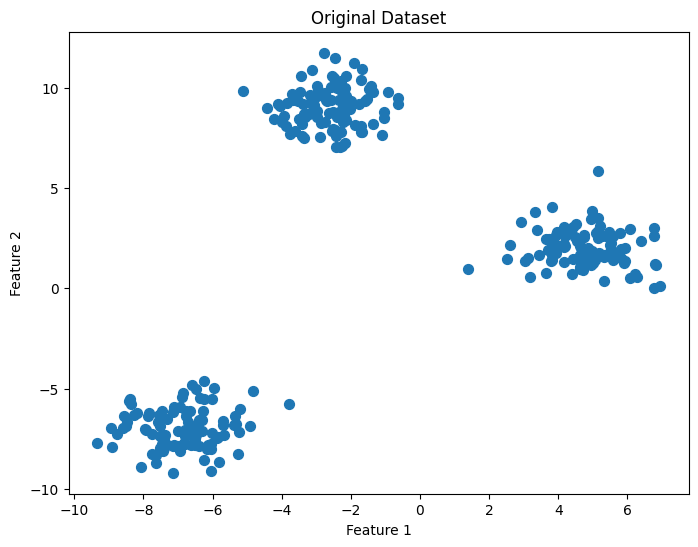

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    s=50
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Dataset")

plt.show()

# Applying K-Means

We know that the dataset was generated with 3 groups.

Therefore, we will initially set:

$$
K = 3
$$

We use `KMeans` from scikit-learn.

In [5]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


# Cluster Labels

After fitting the model, every observation receives a cluster label.

The labels are:

- 0
- 1
- 2

These numbers are simply identifiers.

For example:

```text
0 → Cluster 1
1 → Cluster 2
2 → Cluster 3

In [6]:
labels = kmeans.labels_

labels[:20]

array([1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0],
      dtype=int32)

## Add Cluster Labels to DataFrame

In [7]:
df["Cluster"] = labels

df.head()

,Feature_1,Feature_2,Cluster
0,-7.338988,-7.729954,1
1,-7.740041,-7.264665,1
2,-1.686653,7.793442,0
3,4.422198,3.071947,2
4,-8.917752,-7.888196,1


# Cluster Centroids

The `cluster_centers_` attribute contains the final centroid of every cluster.

Each centroid represents the center of its cluster.

In [8]:
centroids = kmeans.cluster_centers_

centroids

array([[-2.63323268,  9.04356978],
       [-6.88387179, -6.98398415],
       [ 4.74710337,  2.01059427]])

# Visualizing K-Means Clusters

We can visualize:

- Data points
- Their cluster assignments
- Cluster centroids

This helps us understand how K-Means divided the dataset.

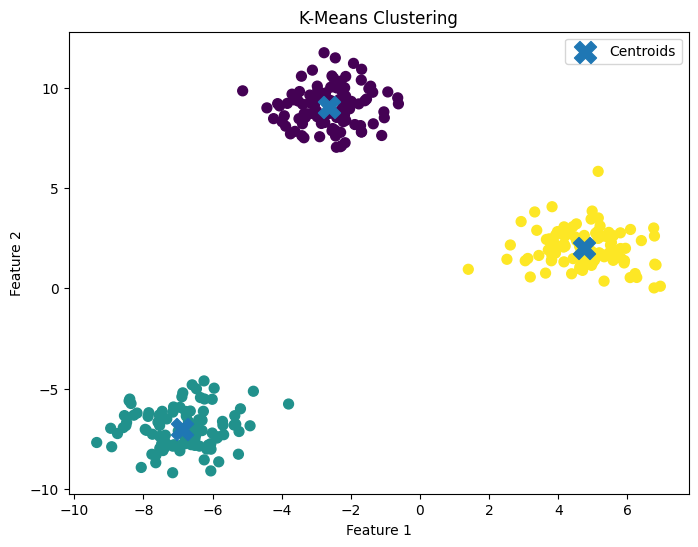

In [9]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    s=50
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")

plt.legend()

plt.show()

# Understanding `n_clusters`

The `n_clusters` parameter determines the number of clusters.

For example:

```python
KMeans(n_clusters=2)

In [10]:
KMeans(n_clusters=2)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",2
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


creates 2 clusters.

In [11]:
KMeans(n_clusters=3)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


creates 3 clusters.

In [12]:
KMeans(n_clusters=5)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


creates 5 clusters.

Choosing K is one of the most important decisions when using K-Means.

A very small K may combine different groups together.

A very large K may divide naturally occurring groups into unnecessary smaller groups.

Therefore, we need methods to help choose K.


---

# Elbow Method

The **Elbow Method** is commonly used to select a suitable value of K.

We train K-Means using several values of K.

For each K, we calculate:

$$
WCSS
$$

which is also called **inertia** in scikit-learn.

As K increases, inertia generally decreases.

However, after a certain point, the improvement becomes much smaller.

This point often looks like an "elbow".

The elbow can be used as a candidate for the number of clusters.

In [13]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X)
    
    inertias.append(model.inertia_)

## Plot Elbow Curve

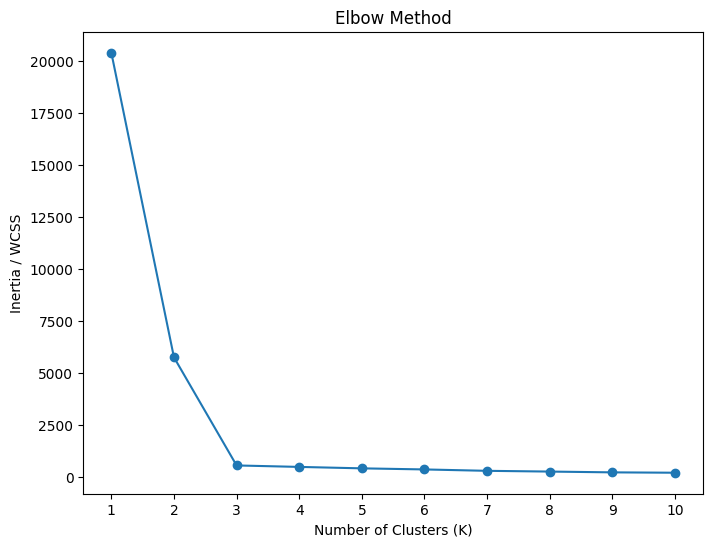

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method")

plt.xticks(k_values)

plt.show()

# Interpreting the Elbow Plot

We look for a point where increasing K provides significantly less improvement.

For this dataset, the elbow should appear around:

$$
K \approx 3
$$

This agrees with the structure of the synthetic dataset.

However, the elbow method is not always perfectly clear.

Therefore, another useful metric is the **Silhouette Score**.

# Silhouette Score

The Silhouette Score measures how well each observation fits within its assigned cluster.

The score ranges from:

$$
-1 \leq S \leq 1
$$

## Interpretation

### Close to +1

The point is well matched to its own cluster and far from other clusters.

### Close to 0

The point lies near the boundary between clusters.

### Negative value

The point may have been assigned to the wrong cluster.

A higher average Silhouette Score generally indicates better-defined clusters.

The Silhouette Score is therefore useful when comparing different values of K.

## Calculate Silhouette Score

In [15]:
score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.8480303059596955


# Comparing Different Values of K

Instead of selecting K based on only one method, we can compare several candidate values.

For every K, we will calculate:

- Inertia
- Silhouette Score

This gives us more information about the quality of clustering.

In [16]:
results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = model.fit_predict(X)
    
    inertia = model.inertia_
    silhouette = silhouette_score(X, cluster_labels)
    
    results.append({
        "K": k,
        "Inertia": inertia,
        "Silhouette Score": silhouette
    })

results_df = pd.DataFrame(results)

results_df

,K,Inertia,Silhouette Score
0,2,5763.464789,0.704944
1,3,566.859551,0.848030
2,4,496.427953,0.663698
3,5,427.128654,0.490127
4,6,375.033158,0.516806
5,7,308.198366,0.358031
6,8,272.405731,0.362563
7,9,234.280723,0.371340
8,10,217.046734,0.360608


## Plot Silhouette Scores

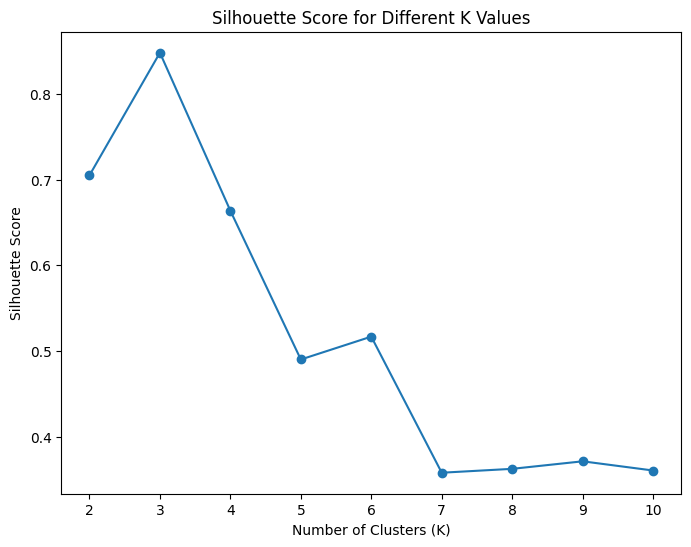

In [17]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["K"],
    results_df["Silhouette Score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

# Feature Scaling

K-Means is a distance-based algorithm.

Therefore, the scale of the features can strongly affect clustering.

Suppose we have:

- Age: 18–80
- Income: 20,000–2,000,000

Income has a much larger numerical scale.

Without scaling, income may dominate the distance calculation.

A common solution is **Standardization**.

The standardized value is:

$$
z =
\frac{x-\mu}{\sigma}
$$

where:

- $x$ = original value
- $\mu$ = mean
- $\sigma$ = standard deviation

After standardization, features generally have:

- Mean ≈ 0
- Standard deviation ≈ 1

## Apply StandardScaler

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.17252292, -1.37037478],
       [-1.25431875, -1.30020394],
       [-0.01971253,  0.97072996],
       [ 1.22620543,  0.25867467],
       [-1.49451639, -1.39423947]])

## K-Means on Scaled Data

In [19]:
kmeans_scaled = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

scaled_labels = kmeans_scaled.fit_predict(X_scaled)

scaled_labels[:20]

array([1, 1, 0, 2, 1, 2, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 2, 0, 0],
      dtype=int32)

# Predicting the Cluster of New Data

After training K-Means, we can assign new observations to the nearest cluster centroid.

Suppose we receive a new data point:

$$
x = (2, 3)
$$

We can use the trained model to determine which cluster it belongs to.

In [20]:
new_point = np.array([[2, 3]])

predicted_cluster = kmeans.predict(new_point)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


# Predicting with a Scaled Model

If the model was trained using scaled data, new observations must also be scaled using the **same scaler**.

We should never fit a new scaler on the new observation.

Instead:

1. Fit the scaler on training data.
2. Transform training data.
3. Use the same scaler to transform new data.
4. Pass the transformed data to K-Means.

In [21]:
new_point = np.array([[2, 3]])

new_point_scaled = scaler.transform(new_point)

predicted_cluster = kmeans_scaled.predict(new_point_scaled)

print("Predicted Cluster:", predicted_cluster[0])

Predicted Cluster: 2


# K-Means Inertia

After fitting K-Means, we can access:


In [22]:
model.inertia_

217.04673403201656

This represents the sum of squared distances between observations and their assigned centroids.

Mathematically:

$$ Inertia = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i-\mu_k||^2 $$

Lower inertia means the observations are closer to their assigned centroids.

However, inertia will generally decrease when K increases.

Therefore, inertia alone should not be used to choose K.

This is why the Elbow Method is useful.

In [23]:
print("Inertia:", kmeans.inertia_)

Inertia: 566.8595511244131


# Important K-Means Parameters

Some important parameters of `KMeans` are:

## `n_clusters`

Number of clusters.


In [24]:
KMeans(n_clusters=3)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


n_init

Number of times K-Means is run with different centroid initializations.

In [25]:
KMeans(n_clusters=3, n_init=10)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


Running multiple initializations can reduce the chance of getting a poor solution.

max_iter

Maximum number of iterations for one run.

In [26]:
KMeans(
    n_clusters=3,
    max_iter=300
)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


random_state

Controls reproducibility.

In [27]:
KMeans(
    n_clusters=3,
    random_state=42
)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'



---


# Practical Example: Customer Segmentation

One common application of K-Means is customer segmentation.

Suppose we have customers described by:

- Annual Income
- Spending Score

We want to automatically divide customers into groups.

For example:

- Low income / Low spending
- Low income / High spending
- High income / Low spending
- High income / High spending

The business can then create different strategies for each segment.

In [28]:
np.random.seed(42)

income = np.random.randint(20000, 120000, 300)
spending_score = np.random.randint(1, 101, 300)

customers = pd.DataFrame({
    "Annual_Income": income,
    "Spending_Score": spending_score
})

customers.head()

,Annual_Income,Spending_Score
0,35795,38
1,20860,84
2,96820,99
3,74886,89
4,26265,99


## Visualize Customer Data

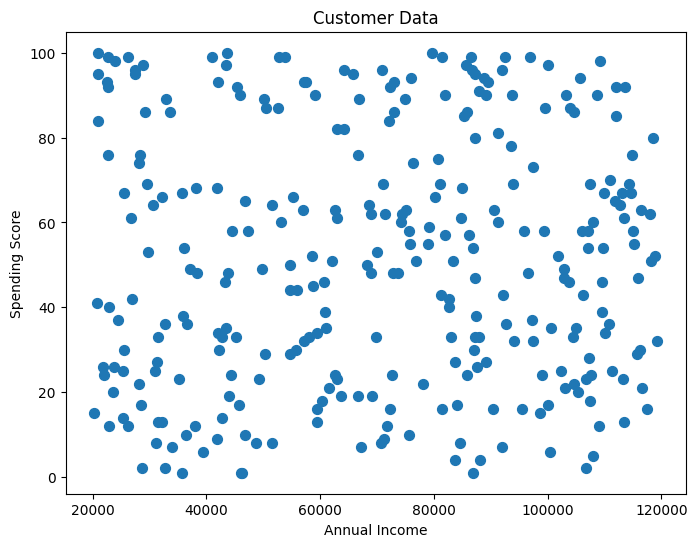

In [29]:
plt.figure(figsize=(8, 6))

plt.scatter(
    customers["Annual_Income"],
    customers["Spending_Score"],
    s=50
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Data")

plt.show()

## Scale Customer Features

In [30]:
customer_scaler = StandardScaler()

customer_scaled = customer_scaler.fit_transform(
    customers[
        ["Annual_Income", "Spending_Score"]
    ]
)

customer_scaled[:5]

array([[-1.18629532, -0.43952988],
       [-1.69362641,  1.12334369],
       [ 0.88667954,  1.63297637],
       [ 0.14159752,  1.29322125],
       [-1.51002249,  1.63297637]])

## Find Suitable K

In [31]:
customer_inertias = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(customer_scaled)
    
    customer_inertias.append(model.inertia_)

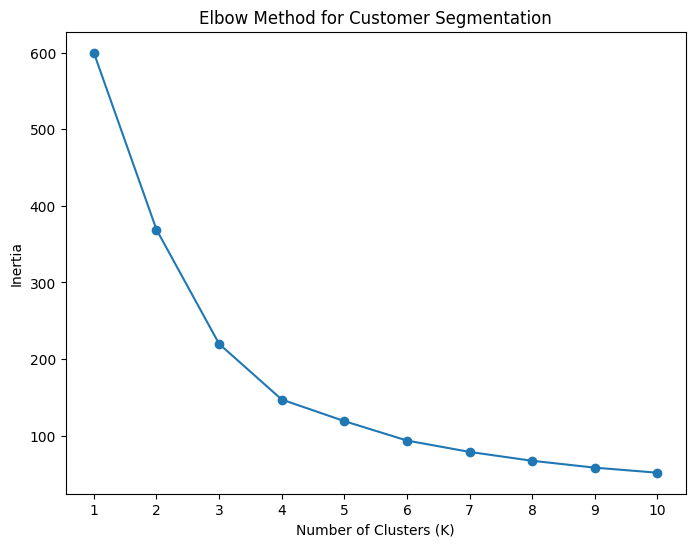

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(
    range(1, 11),
    customer_inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Customer Segmentation")

plt.xticks(range(1, 11))

plt.show()

## Train Final Customer Model

In [33]:
customer_model = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_labels = customer_model.fit_predict(
    customer_scaled
)

customers["Cluster"] = customer_labels

customers.head()

,Annual_Income,Spending_Score,Cluster
0,35795,38,0
1,20860,84,1
2,96820,99,3
3,74886,89,3
4,26265,99,1


## Visualize Customer Clusters

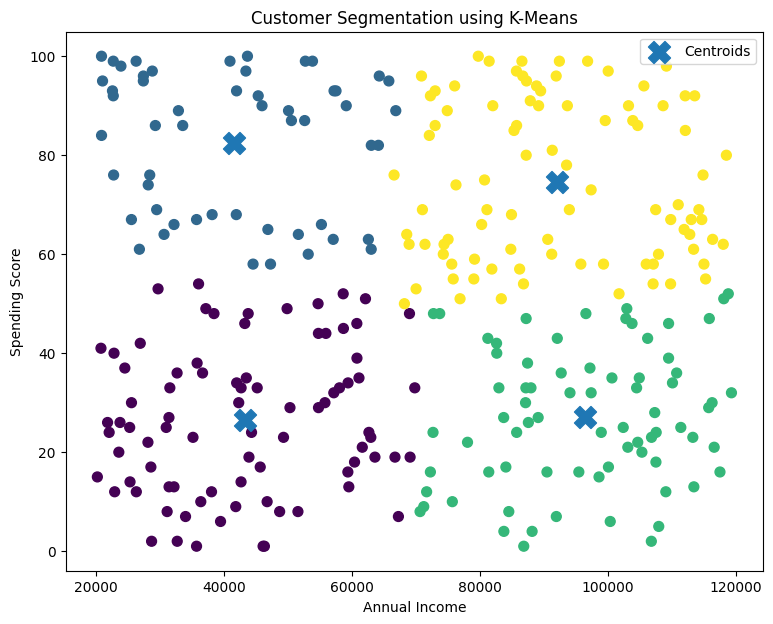

In [34]:
plt.figure(figsize=(9, 7))

plt.scatter(
    customers["Annual_Income"],
    customers["Spending_Score"],
    c=customers["Cluster"],
    s=50
)

centers_original = customer_scaler.inverse_transform(
    customer_model.cluster_centers_
)

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means")

plt.legend()

plt.show()

# Analyzing the Clusters

After clustering, we should not simply stop at the cluster labels.

We should analyze the characteristics of each cluster.

For example, we can calculate the average:

- Annual Income
- Spending Score

for each cluster.

In [35]:
cluster_summary = customers.groupby("Cluster")[
    ["Annual_Income", "Spending_Score"]
].mean()

cluster_summary

,Annual_Income,Spending_Score
Cluster,,
0,43345.409639,26.433735
1,41506.867925,82.547170
2,96426.013514,27.040541
3,92024.688889,74.566667


# Limitation: Choosing K

One major limitation of K-Means is that the number of clusters must usually be specified before training.

The algorithm does not automatically know the correct number of clusters.

We can use techniques such as:

- Elbow Method
- Silhouette Score
- Domain knowledge
- Visualization

However, there is not always one objectively correct value of K.

# Limitations of K-Means

K-Means has several important limitations.

## 1. Need to Choose K

We usually need to specify the number of clusters beforehand.

## 2. Sensitive to Initialization

Different initial centroid positions can produce different results.

Using multiple initializations helps reduce this problem.

## 3. Sensitive to Feature Scale

Because K-Means uses distances, features with larger scales can dominate.

Feature scaling is often important.

## 4. Sensitive to Outliers

Extreme observations can significantly affect centroid locations.

## 5. Assumes Roughly Compact Clusters

K-Means works best when clusters are relatively compact and separated.

## 6. Struggles with Non-Spherical Clusters

K-Means may perform poorly when clusters have complex shapes.

## 7. Can Produce Local Optima

The optimization process does not necessarily find the globally optimal clustering.

# Advantages of K-Means

## 1. Simple

K-Means is relatively easy to understand and implement.

## 2. Fast

It can be computationally efficient for many datasets.

## 3. Scalable

K-Means can work well with relatively large datasets.

## 4. Easy to Interpret

The resulting clusters and centroids are relatively easy to understand.

## 5. Widely Used

It has applications in:

- Marketing
- Customer segmentation
- Image processing
- Data compression
- Pattern recognition
- Exploratory analysis

# K-Means vs Other Clustering Algorithms

K-Means is not the only clustering algorithm.

## K-Means

- Centroid-based
- Requires K
- Fast
- Works well for compact clusters

## Hierarchical Clustering

- Creates a hierarchy of clusters
- Can be visualized using a dendrogram
- Does not require choosing all clusters at the beginning

## DBSCAN

- Density-based
- Can identify arbitrarily shaped clusters
- Can identify noise/outliers
- Does not require specifying the number of clusters

## Gaussian Mixture Models

- Probabilistic clustering
- Produces probabilities of cluster membership
- More flexible cluster shapes than basic K-Means

The appropriate algorithm depends on the structure of the dataset.

# Complete K-Means Example

The following example combines the main steps into one workflow:

1. Create data
2. Scale features
3. Choose K
4. Train K-Means
5. Obtain cluster labels
6. Obtain centroids
7. Evaluate clustering
8. Visualize the result

Inertia: 18.26315933089595
Silhouette Score: 0.8482330810203894


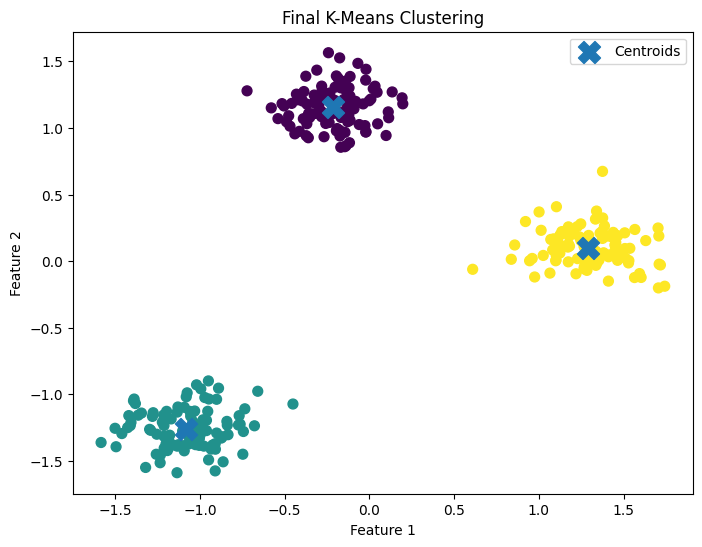

In [36]:
# Create dataset
X, _ = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train K-Means
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_scaled)

# Calculate evaluation metrics
inertia = model.inertia_
silhouette = silhouette_score(
    X_scaled,
    labels
)

# Print results
print("Inertia:", inertia)
print("Silhouette Score:", silhouette)

# Visualize
plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=labels,
    s=50
)

plt.scatter(
    model.cluster_centers_[:, 0],
    model.cluster_centers_[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final K-Means Clustering")

plt.legend()

plt.show()

# Key Concepts to Remember

## K-Means

An unsupervised clustering algorithm.

## K

Number of clusters.

## Centroid

The mean position of observations assigned to a cluster.

## Euclidean Distance

Common distance measure used by K-Means.

## Inertia / WCSS

Measures the total squared distance between observations and their assigned centroids.

Lower is better, but inertia always tends to decrease as K increases.

## Elbow Method

Used to identify a reasonable value of K by examining the reduction in inertia.

## Silhouette Score

Measures how well observations fit their assigned clusters.

Higher values generally indicate better-separated clusters.

## Feature Scaling

Often important because K-Means is distance-based.

## `labels_`

Contains the cluster assigned to each observation.

## `cluster_centers_`

Contains the final centroid coordinates.

## `predict()`

Assigns new observations to the nearest learned cluster.

# Summary

K-Means is an important unsupervised learning algorithm used to divide observations into groups.

The core process is:

$$
\boxed{
\text{Initialize}
\rightarrow
\text{Assign}
\rightarrow
\text{Update}
\rightarrow
\text{Repeat}
}
$$

The algorithm minimizes the within-cluster sum of squared distances:

$$
WCSS =
\sum_{k=1}^{K}
\sum_{x_i \in C_k}
||x_i-\mu_k||^2
$$

Important concepts covered in this notebook:

- Clustering
- K-Means intuition
- Centroids
- Euclidean distance
- K-Means objective function
- Cluster assignment
- Centroid updates
- Inertia / WCSS
- Elbow Method
- Silhouette Score
- Feature scaling
- Prediction for new observations
- Customer segmentation
- Advantages and limitations

K-Means is particularly effective when the data contains relatively compact, well-separated groups.

However, it can struggle with outliers, different feature scales, non-spherical clusters, and situations where the correct number of clusters is unclear.